In [2]:
import cv2
import mediapipe as mp
import numpy as np
import os
os.chdir(r"D:\proj-python\Videos")

# MEAN SHIFT Tracking

In [30]:

cap=cv2.VideoCapture("Vehicle Dataset Sample 3.mp4")
ret,frame=cap.read()
# x,y,w,h=200,400,100,50
# track_window=[(x,y,w,h)]
# roi=frame[y:y+h,x:x+w]
roi=cv2.selectROI(frame,False)
track_window=roi
roi=frame[int(roi[1]):int(roi[1]+roi[3]),int(roi[0]):int(roi[0]+roi[2])]
roi_hsv=cv2.cvtColor(roi,cv2.COLOR_BGR2HSV)
mask=cv2.inRange(roi_hsv,np.array((0.,60.,32.)),np.array((180.,255.,255.)))
roi_hist=cv2.calcHist([roi_hsv],[0],mask,[180],[0,180])
cv2.normalize(roi_hist,roi_hist,0,255,cv2.NORM_MINMAX)
term_crit=(cv2.TERM_CRITERIA_EPS|cv2.TERM_CRITERIA_COUNT,100,1)

fps = cap.get(cv2.CAP_PROP_FPS)
delay = int((1000 / fps) * 1.5)

while True:
    ret,frame=cap.read()
    if ret==True:
        hsv=cv2.cvtColor(frame,cv2.COLOR_BGR2HSV)
        dst=cv2.calcBackProject([hsv],[0],roi_hist,[0,180],1)
        ret,track_window=cv2.meanShift(dst,track_window,term_crit)
        x,y,w,h=track_window
        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
        cv2.imshow("final_image",frame)
        cv2.imshow("dst",dst)
        key=cv2.waitKey(delay)
        if key==ord("q"):
            break
    else:
        break
cap.release()
cv2.destroyAllWindows()

# CAM SHIFT Tracking

In [35]:
cap=cv2.VideoCapture("Vehicle Dataset Sample 3.mp4")
ret,frame=cap.read()
roi=cv2.selectROI(frame,False)
track_window=roi
roi=frame[int(roi[1]):int(roi[1]+roi[3]),int(roi[0]):int(roi[0]+roi[2])]
roi_hsv=cv2.cvtColor(roi,cv2.COLOR_BGR2HSV)
mask=cv2.inRange(roi_hsv,np.array((0.,60.,32.)),np.array((180.,255.,255.)))
roi_hist=cv2.calcHist([roi_hsv],[0],mask,[180],[0,180])
cv2.normalize(roi_hist,roi_hist,0,255,cv2.NORM_MINMAX)
term_crit=(cv2.TERM_CRITERIA_EPS|cv2.TERM_CRITERIA_COUNT,100,1)

fps = cap.get(cv2.CAP_PROP_FPS)
delay = int((1000 / fps) * 1.5)
while True:
    ret, frame=cap.read()
    if not ret:
        break
    hsv=cv2.cvtColor(frame,cv2.COLOR_BGR2HSV)
    dst=cv2.calcBackProject([hsv],[0],roi_hist,[0,180],1)
    ret,track_window=cv2.CamShift(dst,track_window,term_crit)
    print("ret",ret)
    print("track_window",track_window)
    x,y,w,h=track_window
    pts=cv2.boxPoints(ret)
    pts=np.array(pts,int)
    cv2.polylines(frame,[pts],True,(0,255,0),2,cv2.LINE_AA)
    # cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),2)
    cv2.imshow("final_image",frame)
    cv2.imshow("dst",dst)
    key=cv2.waitKey(delay)
    if key==ord("q"):
            break
     
cap.release()
cv2.destroyAllWindows()

ret ((293.0, 101.5), (40.032371520996094, 58.90692138671875), 0.9267933368682861)
track_window (272, 71, 42, 61)
ret ((293.0, 99.5), (43.06913757324219, 64.6514663696289), 12.522138595581055)
track_window (271, 67, 44, 65)
ret ((293.5, 100.0), (41.97581481933594, 63.206642150878906), 8.810859680175781)
track_window (272, 68, 43, 64)
ret ((292.5, 99.5), (44.80149841308594, 65.15039825439453), 177.87742614746094)
track_window (269, 66, 47, 67)
ret ((294.5, 98.0), (47.4585075378418, 66.55955505371094), 9.91787338256836)
track_window (270, 64, 49, 68)
ret ((293.5, 98.5), (47.27460479736328, 67.94513702392578), 7.439733028411865)
track_window (269, 64, 49, 69)
ret ((293.0, 98.0), (49.837852478027344, 68.41963195800781), 4.430600166320801)
track_window (267, 63, 52, 70)
ret ((293.0, 96.5), (54.46702194213867, 72.67782592773438), 3.4928386211395264)
track_window (265, 59, 56, 75)
ret ((294.5, 93.0), (61.18062210083008, 82.07324981689453), 177.03826904296875)
track_window (263, 51, 63, 84)
ret

# DBSCAN CLUSTERING

clusters: {0, 1, 2, 3}


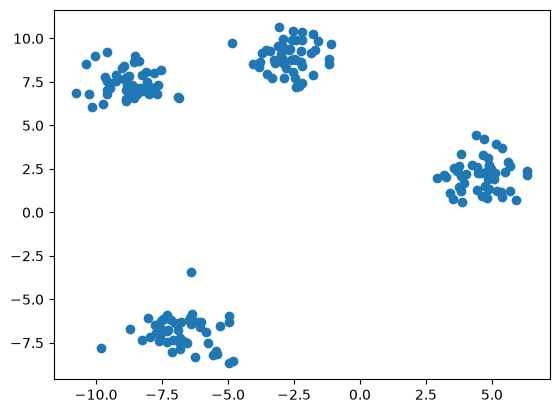

In [17]:
from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors
import seaborn as sns
import matplotlib.pyplot as plt
x,y=make_blobs(n_samples=200,centers=4,cluster_std=0.9,random_state=42)
print("clusters:",set(y))
plt.scatter(x[:,0],x[:,1])

In [13]:
from sklearn.cluster import DBSCAN
import numpy as np
clustering=DBSCAN(eps=0.6,min_samples=5).fit_predict(x)
print(clustering)

[ 2 -1  0  0  1  1  2  0 -1  1  1  2  2  1  1  1  3  0  1  1  1  1  0  3
  0  3  3  1  3  2  1  1 -1  0  3  2  0 -1  0  3  1  3  1  1 -1  2  2  1
  2  3 -1  3  0  2  3  3  1  1  3  2  0  2  1  0  0  1  2  3  0  3  3  0
  3  1  2  1  2  3 -1  3  3  2 -1  0  0  0  0  3  2  0  1  3  2  2  2  0
  3  2  1  3  0  0  3  1  3  2  0  1  1  0  2  1  3  0  3  0  0  3  3  3
 -1  1  2  0  0  2  3  2  2  3  1  1  3  0  0  2  1  1  3  1  2  3 -1  2
  2  3  2  0  1  1  3  0  2  0  1  0  0  2  2  2  3  2  2  0  3  1  2  2
  1  2  0  3  1  1  2  1 -1  3  3  1  3  1  0  0  0 -1  2  2  2  3  3  1
  0  0  3  0 -1  3  1  2]
